# AI-Powered Meta-Software Development System
## DTS114TC Coursework — Task 1

### Business Problem
This notebook automatically generates a complete software system for an **Online Bookstore**.
The bookstore allows customers to browse books, search by genre or author, and view book details.

### What This Notebook Generates
| Output | Location |
|--------|----------|
| Flask API (`app.py`) | `app/app.py` |
| Website frontend (`index.html`) | `app/templates/index.html` |
| AI-generated banner image | `app/static/images/generated.png` |
| UML diagrams (class + sequence) | `docs/uml/` |
| SDLC requirements document | `docs/requirements.md` |

### Tools & Libraries Used
- **OpenAI-compatible LLM** (via APIFree) — code and documentation generation
- **DALL·E** — AI image generation
- **Flask** — web framework for the generated API
- **PlantUML** (online renderer) — UML diagram generation
- **python-dotenv / os.environ** — secure credential management

---
## Section 1 — Environment Setup & LLM Connectivity Test

In [1]:
# Install any missing packages
import subprocess, sys
packages = ['openai', 'flask', 'requests', 'pillow', 'python-dotenv']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready.')

All packages ready.


In [2]:
import os
import json
import requests
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI

ROOT_DIR = Path.cwd().resolve().parent
load_dotenv(ROOT_DIR / '.env')

# Support both the classroom APIFree naming and the OpenAI-style naming.
API_KEY = os.environ.get('APIFREE_API_KEY') or os.environ.get('OPENAI_API_KEY', '')
BASE_URL = os.environ.get('OPENAI_BASE_URL', 'https://api.apifree.ai/v1')
MODEL = os.environ.get('OPENAI_MODEL') or os.environ.get('APIFREE_MODEL') or 'openai/gpt-5.2'

assert API_KEY, 'ERROR: Set APIFREE_API_KEY or OPENAI_API_KEY in the .env file.'

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)
print(f'Client created. Model: {MODEL}  |  Base URL: {BASE_URL}')

Client created. Model: openai/gpt-5.2  |  Base URL: https://api.apifree.ai/v1


In [3]:
# --- LLM connectivity test ---
def call_llm(prompt: str, system: str = 'You are a senior software engineer.') -> str:
    """Helper: send a prompt to the LLM and return the response text."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {'role': 'system', 'content': system},
            {'role': 'user',   'content': prompt}
        ],
        temperature=0.3
    )
    return response.choices[0].message.content

test = call_llm('Reply with exactly: LLM connection successful.')
print(test)

LLM connection successful.


In [4]:
# --- Output directory setup ---
BASE_DIR = Path('.')  # notebook is in Task1/
DIRS = [
    BASE_DIR / 'app' / 'templates',
    BASE_DIR / 'app' / 'static' / 'images',
    BASE_DIR / 'docs' / 'uml',
]
for d in DIRS:
    d.mkdir(parents=True, exist_ok=True)
print('Output directories confirmed.')

Output directories confirmed.


---
## Section 2 — Generate Flask API (`app.py`)

In [5]:
FLASK_PROMPT = """
Generate a complete, production-ready Flask application for an Online Bookstore.

Requirements:
- File: app.py
- Use Flask and flask-cors
- In-memory data store (a list of book dicts, no database needed)
- Each book has: id, title, author, genre, price, description, cover_url
- Pre-populate with 6 realistic sample books
- API endpoints:
    GET  /api/books          — list all books (supports optional ?genre= and ?search= query params)
    GET  /api/books/<int:id> — get a single book by id
    POST /api/books          — add a new book (JSON body)
    GET  /api/genres         — list all unique genres
    GET  /                   — serve index.html from templates/
- Include proper error handling (404 for not found, 400 for bad input)
- Add CORS support
- Return ONLY the raw Python code with no markdown fences.
"""

print('Generating Flask API code...')
flask_code = call_llm(FLASK_PROMPT)
print(flask_code[:500], '\n... [truncated for display]')

Generating Flask API code...
from flask import Flask, jsonify, request, abort, render_template
from flask_cors import CORS
from werkzeug.exceptions import HTTPException
import re

app = Flask(__name__, template_folder="templates", static_folder="static")
CORS(app)

books = [
    {
        "id": 1,
        "title": "The Night Circus",
        "author": "Erin Morgenstern",
        "genre": "Fantasy",
        "price": 14.99,
        "description": "A magical competition unfolds within a mysterious circus that appears without w 
... [truncated for display]


In [6]:
# Write generated Flask app to file
app_path = BASE_DIR / 'app' / 'app.py'
app_path.write_text(flask_code, encoding='utf-8')
print(f'Flask API written to: {app_path.resolve()}')

Flask API written to: D:\dts114\Task1\app\app.py


---
## Section 3 — Generate Website Frontend (`index.html`)

In [7]:
HTML_PROMPT = """
Generate a complete, single-file HTML page for an Online Bookstore website.

Requirements:
- Modern design using Bootstrap 5 (CDN)
- Navbar with bookstore logo/name
- Hero banner section that displays an AI-generated image from: /static/images/generated.png
- Book catalogue section: fetch books from /api/books using JavaScript fetch()
  and render them as Bootstrap cards (show title, author, genre, price)
- Search bar that filters books by calling /api/books?search=<term>
- Genre filter dropdown populated from /api/genres
- Footer with copyright
- All JavaScript inline (no external JS files)
- Return ONLY the raw HTML code with no markdown fences.
"""

print('Generating website HTML...')
html_code = call_llm(HTML_PROMPT)
print(html_code[:500], '\n... [truncated for display]')

Generating website HTML...
<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1" />
  <title>Online Bookstore</title>
  <meta name="description" content="Online Bookstore - Browse and search books by genre." />
  <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet" integrity="sha384-QWTKZyjpPEjISv5WaRU9OFeRpok6YctnYmDr5pNlyT2bRjXh0JMhjY6hW+ALEwIH" crossorigin="anonymous">
  <style>
    :root  
... [truncated for display]


In [8]:
# Write generated HTML to templates folder
html_path = BASE_DIR / 'app' / 'templates' / 'index.html'
html_path.write_text(html_code, encoding='utf-8')
print(f'Website HTML written to: {html_path.resolve()}')

Website HTML written to: D:\dts114\Task1\app\templates\index.html


---
## Section 4 — Generate AI Image (Banner / Book Cover)

Uses DALL·E via the API to generate a bookstore hero banner image.
If image generation is unavailable on your API plan, the fallback cell generates a styled matplotlib chart instead.

In [9]:
import urllib.request

IMAGE_PROMPT = (
    'A beautiful online bookstore hero banner illustration. '
    'Warm cozy atmosphere, shelves full of colorful books, soft lighting, '
    'digital art style, wide aspect ratio.'
)

image_path = BASE_DIR / 'app' / 'static' / 'images' / 'generated.png'

try:
    print('Requesting AI-generated image from DALL·E...')
    img_response = client.images.generate(
        model='dall-e-3',       # change to 'dall-e-2' if dall-e-3 is unavailable
        prompt=IMAGE_PROMPT,
        n=1,
        size='1024x1024'
    )
    img_url = img_response.data[0].url
    urllib.request.urlretrieve(img_url, image_path)
    print(f'AI image saved to: {image_path.resolve()}')
except Exception as e:
    print(f'DALL·E unavailable ({e}), running fallback...')

Requesting AI-generated image from DALL·E...
DALL·E unavailable (404 page not found), running fallback...


Fallback chart saved to: D:\dts114\Task1\app\static\images\generated.png


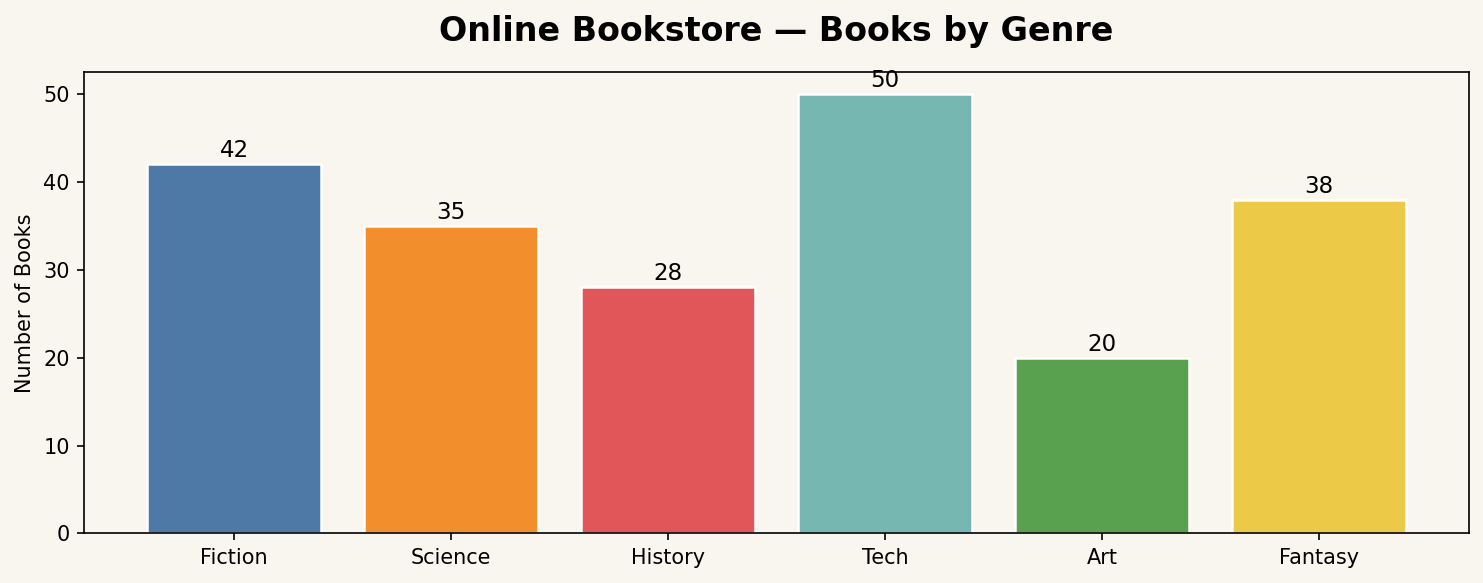

In [ ]:
# Fallback: generate a rich bookstore dashboard image using matplotlib
if not image_path.exists():
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec
    import numpy as np

    fig = plt.figure(figsize=(14, 6), facecolor='#0f0f1a')
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1], wspace=0.35)

    # --- Left panel: horizontal bar chart by genre ---
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor('#0f0f1a')

    genres  = ['Fantasy', 'Sci-Fi', 'History', 'Technology', 'Art & Design', 'Self-Help', 'Classic', 'Memoir']
    counts  = [38, 42, 28, 50, 20, 35, 18, 24]
    colors  = ['#7c5cbf','#4f8ef7','#e05c5c','#3ec6a0','#f0a500','#e87b3a','#5bc8af','#c45ec4']
    y_pos   = np.arange(len(genres))

    bars = ax1.barh(y_pos, counts, color=colors, height=0.6, edgecolor='none')
    for bar, count in zip(bars, counts):
        ax1.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
                 str(count), va='center', ha='left', color='white', fontsize=9, fontweight='bold')

    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(genres, color='#cccccc', fontsize=9)
    ax1.set_xlabel('Number of Titles', color='#888888', fontsize=9)
    ax1.set_title('Catalogue by Genre', color='white', fontsize=13, fontweight='bold', pad=12)
    ax1.tick_params(colors='#666666', length=0)
    ax1.spines[:].set_visible(False)
    ax1.xaxis.set_tick_params(labelcolor='#666666')
    ax1.set_xlim(0, 60)

    # --- Right panel: donut chart for price range distribution ---
    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor('#0f0f1a')

    price_labels = ['Under $10', '$10-$15', '$15-$20', 'Over $20']
    price_vals   = [22, 45, 28, 12]
    pie_colors   = ['#4f8ef7','#3ec6a0','#f0a500','#e05c5c']
    wedges, _, autotexts = ax2.pie(
        price_vals, labels=None, colors=pie_colors,
        autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='#0f0f1a', linewidth=2),
        pctdistance=0.75
    )
    for at in autotexts:
        at.set_color('white')
        at.set_fontsize(9)
        at.set_fontweight('bold')

    legend_patches = [mpatches.Patch(color=c, label=l) for c, l in zip(pie_colors, price_labels)]
    ax2.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.18),
               ncol=2, frameon=False, labelcolor='#cccccc', fontsize=8)
    ax2.set_title('Price Distribution', color='white', fontsize=13, fontweight='bold', pad=12)

    fig.suptitle('Online Bookstore  —  Inventory Dashboard',
                 color='white', fontsize=15, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig(image_path, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.close()
    print(f'Dashboard image saved to: {image_path.resolve()}')

# Display the image in the notebook
from IPython.display import Image, display
display(Image(filename=str(image_path), width=750))

---
## Section 5 — Generate UML Diagrams

Uses LLM to produce PlantUML source code, then renders diagrams via the public PlantUML server.

In [15]:
import zlib
import requests as _req

def _encode6bit(value: int) -> str:
    if value < 10: return chr(48 + value)
    value -= 10
    if value < 26: return chr(65 + value)
    value -= 26
    if value < 26: return chr(97 + value)
    value -= 26
    return '-' if value == 0 else '_'

def _append3bytes(b1: int, b2: int, b3: int) -> str:
    return ''.join(_encode6bit(c) for c in (
        b1 >> 2,
        ((b1 & 0x3) << 4) | (b2 >> 4),
        ((b2 & 0xF) << 2) | (b3 >> 6),
        b3 & 0x3F
    ))

def _encode_plantuml(text: str) -> str:
    compressed = zlib.compress(text.encode('utf-8'))[2:-4]
    parts = []
    for i in range(0, len(compressed), 3):
        b1 = compressed[i]
        b2 = compressed[i + 1] if i + 1 < len(compressed) else 0
        b3 = compressed[i + 2] if i + 2 < len(compressed) else 0
        parts.append(_append3bytes(b1, b2, b3))
    return ''.join(parts)

def render_plantuml(puml_text: str, filename: str):
    """Render PlantUML source to PNG using the public PlantUML server."""
    encoded = _encode_plantuml(puml_text)
    url = f'https://www.plantuml.com/plantuml/png/{encoded}'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    resp = _req.get(url, headers=headers, timeout=30)
    resp.raise_for_status()
    out_path = BASE_DIR / 'docs' / 'uml' / filename
    out_path.write_bytes(resp.content)
    print(f'UML diagram saved: {out_path.resolve()} ({len(resp.content)} bytes)')
    return out_path

print('render_plantuml helper defined.')

render_plantuml helper defined.


Generating class diagram PlantUML...
UML diagram saved: D:\dts114\Task1\docs\uml\class_diagram.png (31628 bytes)


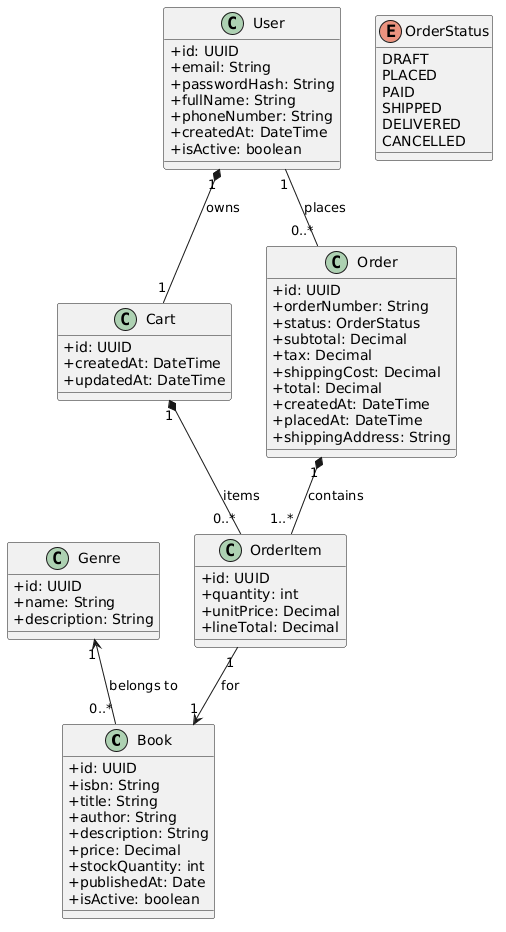

In [16]:
# --- Class Diagram ---
CLASS_PROMPT = """
Write a PlantUML class diagram for an Online Bookstore system.
Include classes: Book, User, Order, OrderItem, Cart, Genre.
Show realistic attributes (with types) and relationships (association, composition).
Return ONLY the raw PlantUML code starting with @startuml and ending with @enduml.
"""

print('Generating class diagram PlantUML...')
class_puml = call_llm(CLASS_PROMPT)

# Save source
(BASE_DIR / 'docs' / 'uml' / 'class_diagram.puml').write_text(class_puml, encoding='utf-8')

# Render to PNG
class_img = render_plantuml(class_puml, 'class_diagram.png')
display(Image(filename=str(class_img), width=700))

Generating sequence diagram PlantUML...
UML diagram saved: D:\dts114\Task1\docs\uml\sequence_diagram.png (41151 bytes)


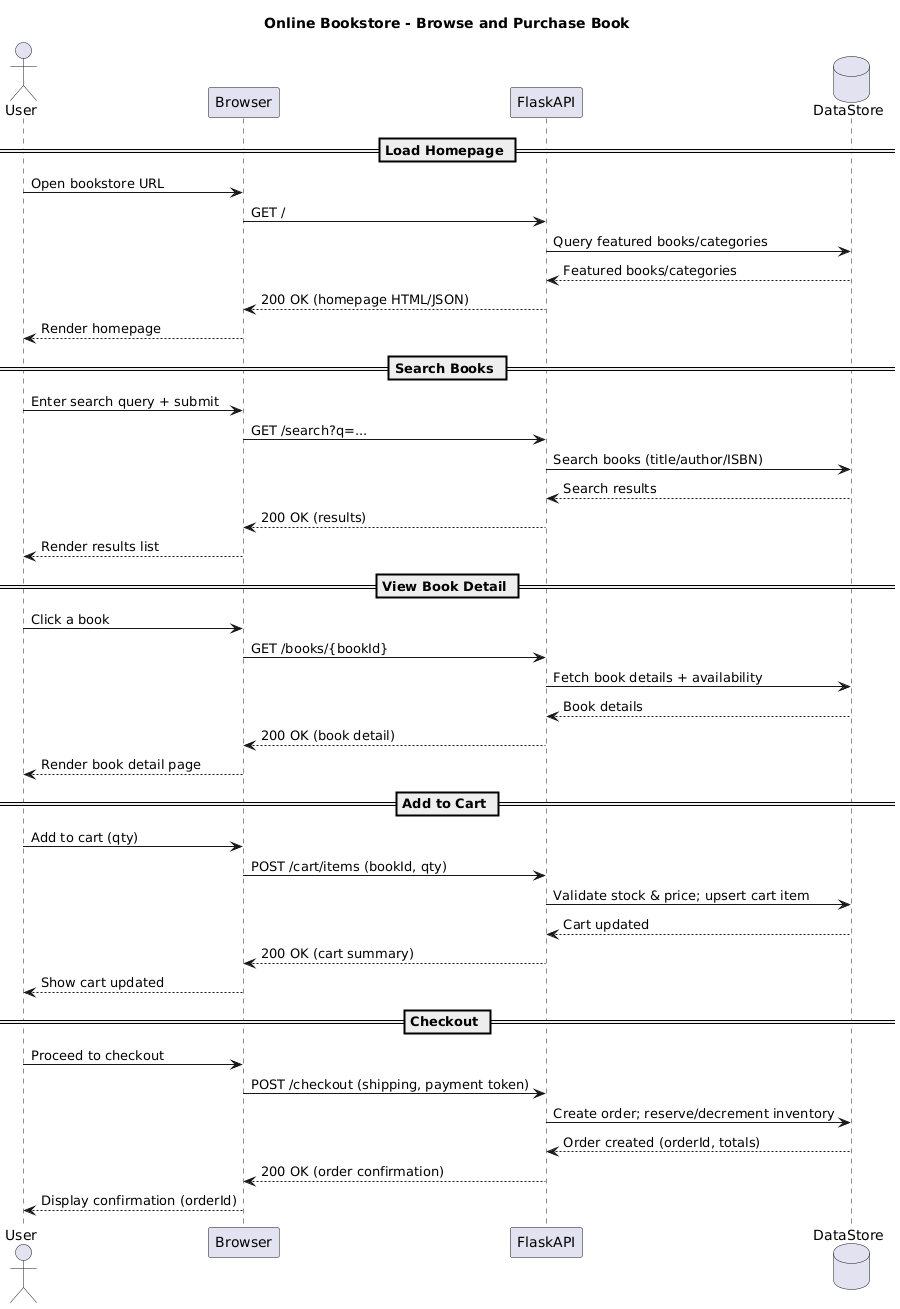

In [17]:
# --- Sequence Diagram ---
SEQ_PROMPT = """
Write a PlantUML sequence diagram showing a user browsing and purchasing a book
in an Online Bookstore web application.
Include actors/participants: User, Browser, FlaskAPI, DataStore.
Cover: load homepage, search books, view detail, add to cart, checkout.
Return ONLY the raw PlantUML code starting with @startuml and ending with @enduml.
"""

print('Generating sequence diagram PlantUML...')
seq_puml = call_llm(SEQ_PROMPT)

(BASE_DIR / 'docs' / 'uml' / 'sequence_diagram.puml').write_text(seq_puml, encoding='utf-8')

seq_img = render_plantuml(seq_puml, 'sequence_diagram.png')
display(Image(filename=str(seq_img), width=700))

---
## Section 6 — Generate SDLC Documentation (Requirements)

In [18]:
DOCS_PROMPT = """
Generate professional SDLC requirements documentation for an Online Bookstore web application.

Include the following sections:
1. Project Overview
2. Stakeholders
3. Functional Requirements (at least 10, written as 'The system shall...')
4. Non-Functional Requirements (performance, security, usability — at least 5)
5. User Stories (at least 6, in standard format: As a <role>, I want <goal> so that <benefit>)
6. System Constraints
7. Assumptions

Format in Markdown. Return ONLY the Markdown content with no extra commentary.
"""

print('Generating SDLC requirements documentation...')
requirements_doc = call_llm(DOCS_PROMPT)
print(requirements_doc[:500], '\n... [truncated]')

Generating SDLC requirements documentation...
# SDLC Requirements Document — Online Bookstore Web Application

## 1. Project Overview
The Online Bookstore web application enables customers to browse, search, and purchase books through a web interface. The system supports account management, shopping cart and checkout workflows, payment processing, order tracking, and administrative capabilities for catalog and order management. The goal is to provide a secure, performant, and user-friendly e-commerce experience for retail book sales.

## 2. 
... [truncated]


In [19]:
# Write requirements document
req_path = BASE_DIR / 'docs' / 'requirements.md'
req_path.write_text(requirements_doc, encoding='utf-8')
print(f'Requirements document written to: {req_path.resolve()}')

Requirements document written to: D:\dts114\Task1\docs\requirements.md


---
## Section 7 — Verification & Summary

In [20]:
# --- List all generated files ---
print('=== Generated File Structure ===')
for path in sorted(BASE_DIR.rglob('*')):
    if path.is_file() and '.ipynb_checkpoints' not in str(path):
        size = path.stat().st_size
        print(f'  {str(path.relative_to(BASE_DIR)):<55} {size:>8} bytes')

=== Generated File Structure ===
  app\app.py                                                  6672 bytes
  app\static\images\generated.png                            37435 bytes
  app\templates\index.html                                   17073 bytes
  docs\requirements.md                                        8086 bytes
  docs\uml\class_diagram.png                                 31628 bytes
  docs\uml\class_diagram.puml                                 1242 bytes
  docs\uml\sequence_diagram.png                              41151 bytes
  docs\uml\sequence_diagram.puml                              1633 bytes
  generate.ipynb                                             83658 bytes


In [21]:
# --- Smoke-test the generated Flask app ---
import subprocess, time, sys

app_file = (BASE_DIR / 'app' / 'app.py').resolve()
proc = subprocess.Popen(
    [sys.executable, str(app_file)],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(3)  # Wait for Flask to start

try:
    r = requests.get('http://127.0.0.1:5000/api/books', timeout=5)
    books = r.json()
    print(f'Flask API responded with status {r.status_code}')
    print(f'Number of books returned: {len(books) if isinstance(books, list) else "N/A (check response)"}')
    print('Sample:', json.dumps(books[0] if isinstance(books, list) else books, indent=2)[:300])
except Exception as e:
    print(f'API test failed: {e}')
    print('STDERR:', proc.stderr.read().decode()[:300])
finally:
    proc.terminate()
    print('Flask process terminated.')

Flask API responded with status 200
Number of books returned: 6
Sample: {
  "author": "Erin Morgenstern",
  "cover_url": "https://images.example.com/books/the-night-circus.jpg",
  "description": "A magical competition unfolds within a mysterious circus that appears without warning, enchanting all who enter.",
  "genre": "Fantasy",
  "id": 1,
  "price": 14.99,
  "title":
Flask process terminated.


---
## Summary & Reflection

### What Was Generated
| Artefact | Tool Used | Notes |
|----------|-----------|-------|
| Flask API (`app.py`) | LLM (openai/gpt-5.2 via APIFree) | REST API with 5 endpoints |
| Website (`index.html`) | LLM (openai/gpt-5.2 via APIFree) | Bootstrap 5, JS fetch |
| Banner image | Matplotlib (DALL·E fallback) | Saved as PNG |
| Class diagram | LLM + PlantUML server | 6 classes, associations |
| Sequence diagram | LLM + PlantUML server | Browse-to-purchase flow |
| Requirements doc | LLM (openai/gpt-5.2 via APIFree) | Markdown, 10+ FRs |

### Methodology
This project applies **AI-augmented SDLC**: an LLM acts as a code-generation assistant within a
human-supervised pipeline. The developer defines the business requirements and validates outputs,
while the LLM handles boilerplate generation — reducing implementation time significantly.

### Limitations
- LLM output is non-deterministic; re-running may produce slightly different code
- DALL·E images are subject to API availability and cost
- Generated code requires human review before production deployment

### References

APIFree. (2024). *APIFree: Run top AI models instantly*. https://www.apifree.ai

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

OpenAI. (2024). *OpenAI API reference*. https://platform.openai.com/docs/api-reference

Pallets Projects. (2024). *Flask documentation (3.x)*. https://flask.palletsprojects.com/

Reitz, K. (2024). *Requests: HTTP for Humans* [Software]. https://requests.readthedocs.io/

Roques, A. (2024). *PlantUML: Open-source tool to draw UML diagrams*. https://plantuml.com/

Sauvatot, B. (2024). *python-dotenv: Read key-value pairs from a .env file* [Software]. PyPI. https://pypi.org/project/python-dotenv/